In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [5]:
ds = pd.read_csv('loan_approval_dataset.csv')
ds.columns = ds.columns.str.strip()  
ds.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
ds.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [9]:
encoder = LabelEncoder()

ds["education"] = encoder.fit_transform(ds["education"])
ds["self_employed"] = encoder.fit_transform(ds["self_employed"])
ds["loan_status"] = encoder.fit_transform(ds["loan_status"])

In [10]:
X = ds.drop(["loan_id", "loan_status"], axis=1)

y = ds["loan_status"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [13]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Accuracy : 0.968384074941452
Precision: 0.9395770392749244
Recall   : 0.9779874213836478
F1 Score : 0.9583975346687211

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       536
           1       0.94      0.98      0.96       318

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



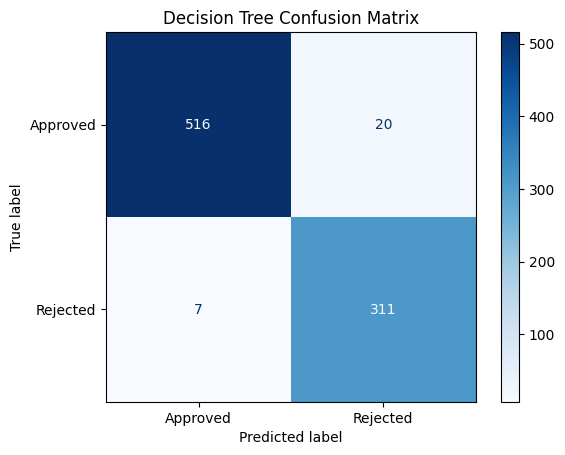

In [14]:
cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Approved", "Rejected"]
)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [15]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [16]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.977751756440281
Precision: 0.9776357827476039
Recall   : 0.9622641509433962
F1 Score : 0.9698890649762282


In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head())

                    Feature  Importance
6               cibil_score    0.809939
5                 loan_term    0.064499
4               loan_amount    0.028938
7  residential_assets_value    0.018168
3              income_annum    0.018060


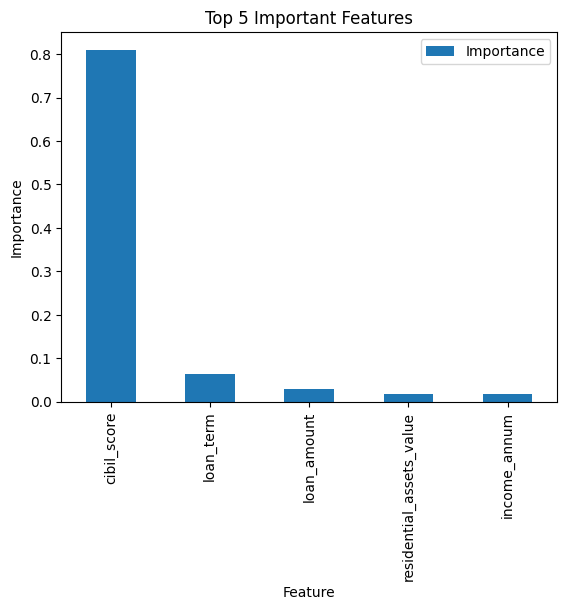

In [18]:
importance.head(5).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 5 Important Features")
plt.ylabel("Importance")
plt.show()

In [19]:
estimators = [50, 100, 200]

accuracies = []

for n in estimators:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    accuracies.append(acc)

    print(f"{n} Trees -> Accuracy = {acc:.4f}")

50 Trees -> Accuracy = 0.9801
100 Trees -> Accuracy = 0.9778
200 Trees -> Accuracy = 0.9778


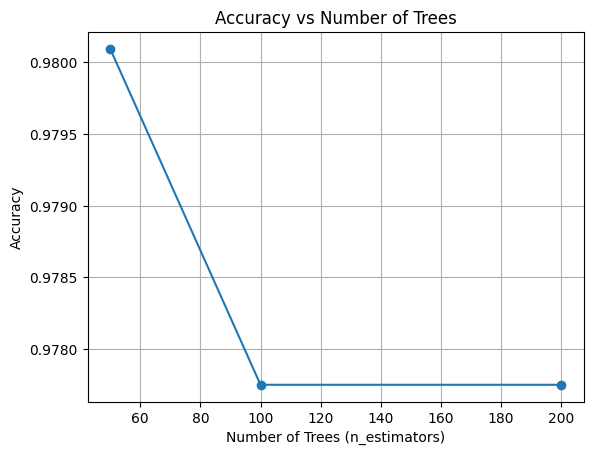

In [20]:
plt.plot(
    estimators,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")

plt.grid(True)

plt.show()

In [21]:
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Decision Tree Accuracy :", dt_acc)
print("Random Forest Accuracy :", rf_acc)

Decision Tree Accuracy : 0.968384074941452
Random Forest Accuracy : 0.977751756440281
